# Homework 2

In this assignment you will train a polynomial regressor, explore log likelihood and train a logistic regressor.

#### Libraries that could possibly be used: numpy, scipy, pandas, scikit-learn, matplotlib, operator

#### Other Notes
 - Don't worry about not being able to achieve high accuracy, it is neither the goal nor the grading standard of **this** assignment. <br >
 - If not specified, you are not required to do hyperparameter tuning, but feel free to do so if you'd like.
 - Discussion materials should be helpful for doing the assignments.

## Exercise 1 - Polynomial Regressor (35 points in total)
We are going to look into model fitting. In the dataset 'cost.csv', the first column is the independent variable: production_output, and the second column is the dependent variable: cost.

### Exercise 1.1 - Split the dataset (5 points)
Import the dataset 'cost.csv' and split them into training and testing set with ratio 70:30.

## Please Ouptput
- The first 5 rows of train and test
- The length of y_test and y_train
- We will be looking at your code, so make it readable. You should be able to do this in < 6 lines

In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
import math
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler


In [22]:
# read in data and split it
cost_df = pd.read_csv('./cost.csv')
X = cost_df['production_output']
y = cost_df['cost']
X_cost_train, X_cost_test, y_cost_train, y_cost_test = train_test_split(X, y, test_size=0.3, random_state=10)

# output
print("cost independent variables: \n", X_cost_test[:5])
print("cost dependent variables: ", y_cost_train[:5])
print("length of y_test: ", len(y_cost_test))
print("length of y_train: ", len(y_cost_train))

cost independent variables: 
 87     2.143940
111    1.275164
10     1.884765
91     1.022044
49     2.170192
Name: production_output, dtype: float64
cost dependent variables:  32     750.559715
52     441.220285
70      30.030642
121    985.351193
144     -5.599248
Name: cost, dtype: float64
length of y_test:  45
length of y_train:  105


### Exercise 1.2 - Polynomial Regression (30 points)
1. Fit polynomial regression models with degree 1,2,3,4.
2. Compute the RMSE and R2 for the training and testing set, for each model.
3. Which model provides the most appropriate prediction? Justify your answer and plot the fitted line for each model.

You should have fit 4 different models to the data and reported RMSE and R2 for train and test for each model.

## Please output:
- **For Each Model:**
    - R2 and RMSE of training and test
    - Fitted line
- Markdown of your answer and justification

In [23]:
print(y_cost_train)

32     750.559715
52     441.220285
70      30.030642
121    985.351193
144     -5.599248
          ...    
113     -4.735819
64     125.140350
15      97.632911
125    238.581649
9       76.409890
Name: cost, Length: 105, dtype: float64


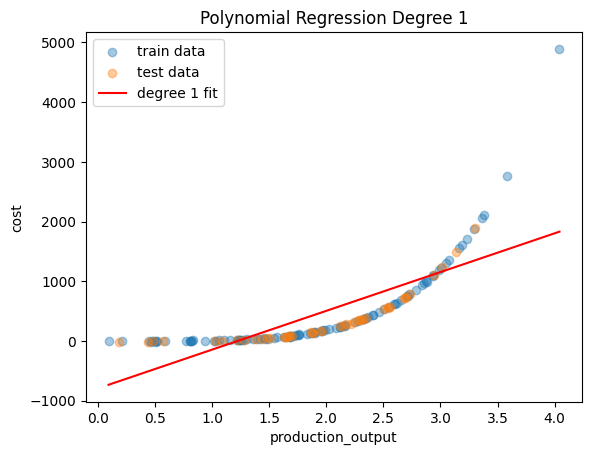

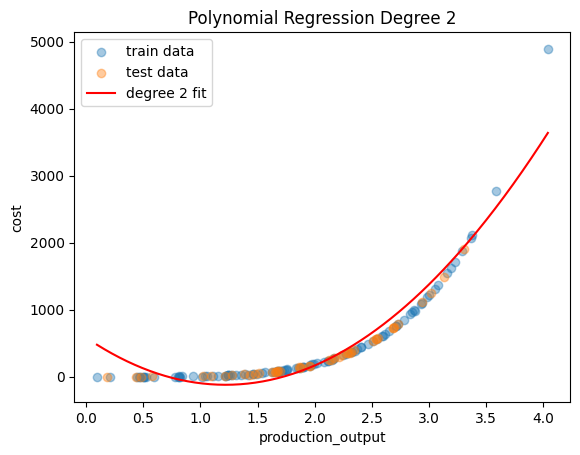

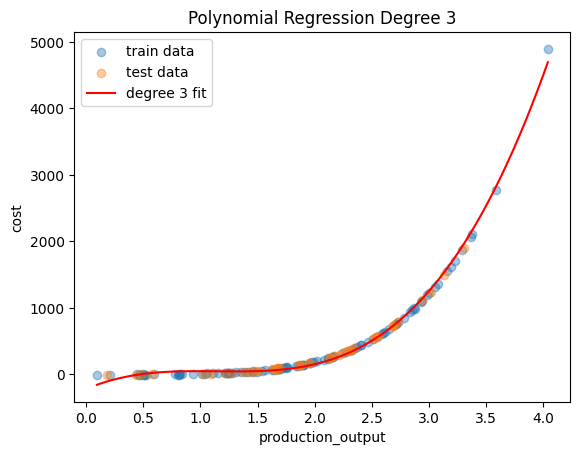

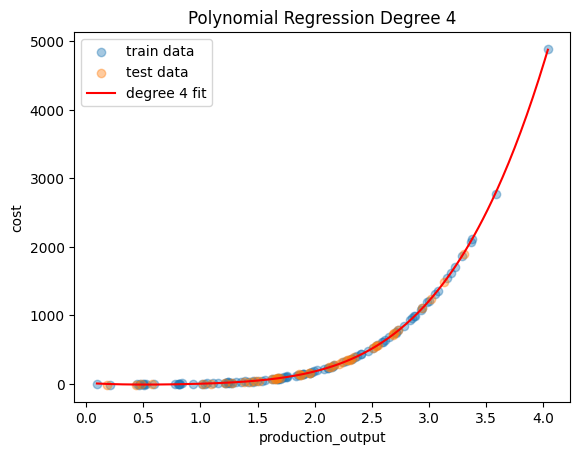

model_1: {'RMSE': 297.79461386163035, 'r2': 0.49382184971564425, 'train_rmse': 435.8894702568781, 'train_r2': 0.49382184971564425}
model_2: {'RMSE': 127.6799927488343, 'r2': 0.9069502059752967, 'train_rmse': 178.67122034728087, 'train_r2': 0.9069502059752967}
model_3: {'RMSE': 29.548625036588906, 'r2': 0.9950163874431293, 'train_rmse': 38.43053508627716, 'train_r2': 0.9950163874431293}
model_4: {'RMSE': 5.876882155324605, 'r2': 0.9998028650251157, 'train_rmse': 5.988345219238347, 'train_r2': 0.9998028650251157}


In [24]:
scores = {}
# need to make X a list of lists
X_cost_train_nest = [[x] for x in X_cost_train]
X_cost_test_nest = [[x] for x in X_cost_test]

for i in range(1, 5):
    # this will apply per model

    # transform X to the appropriate degree
    poly = PolynomialFeatures(degree=i)
    X_poly_train = poly.fit_transform(X_cost_train_nest)
    X_poly_test = poly.transform(X_cost_test_nest) 

    # train model
    model = LinearRegression()
    model.fit(X_poly_train, y_cost_train)
    y_train_pred = model.predict(X_poly_train)  
    y_pred = model.predict(X_poly_test)

    # compute RMSE and R2 for the training and testing set
    train_rmse = root_mean_squared_error(y_cost_train, y_train_pred)
    train_r2 = r2_score(y_cost_train, y_train_pred)
    rmse = root_mean_squared_error(y_cost_test, y_pred)
    r2 = r2_score(y_cost_test, y_pred)

    # plot fitted line
    x_range = np.linspace(X_cost_train.min(), X_cost_train.max(), 300).reshape(-1, 1)
    y_range_pred = model.predict(poly.transform(x_range))
    plt.scatter(X_cost_train, y_cost_train, alpha=0.4, label='train data')
    plt.scatter(X_cost_test, y_cost_test, alpha=0.4, label='test data')
    plt.plot(x_range, y_range_pred, color='red', label=f'degree {i} fit')
    plt.title(f'Polynomial Regression Degree {i}')
    plt.xlabel('production_output')
    plt.ylabel('cost')
    plt.legend()
    plt.show()

    # save results
    result = {"RMSE": rmse, "r2": r2, "train_rmse": train_rmse, "train_r2": r2}
    scores[f'model_{i}'] = result

for key, value in scores.items():
    print(f"{key}: {value}")

The degree 4 model has the best generalization. It has the lowest RMSE and the highest r2. 

## Exercise 2 : Log Likelihood (35 points in total)
Given the small dataset provided (in the table) and an imaginary model ŷ = 0.1 x1 + 0.1 x2:

Variables x1 (Weight) and x2 (Length) are independent and y (Height) is dependent.

Compute the log-likelihood for the model: ŷ = 0.1 x1 + 0.1 x2 , where the dependent variable ŷ represents the prediction for Height. Assuming that the independent variable measurements have normal distribution with STD (σ^2) = 1, please complete the table by calculating the predicted height, squared residual and log-likelihood for each data point. Then, compute and report the log-likelihood for the entire dataset.

Round your answer to 4 d.p. For simplicity, use log base 10.

Hint: $f(y_i)=\frac{1}{\sqrt{2\piσ^2}}e^{\frac{-(y_i-ŷ_i)^2}{2σ^2}}$

Model M1:
Weight x1 | Length x2 | Actual Height y | Predicted Height ŷ | squared residual (y - ŷ )^2 | Log-Likelihood
---|---|---|---|---|---|
7.0 | 50 | 5.80 | 5.7 | 0.01 | -0.4013 |
6.0 | 55 | 5.70 | 6.1 | 0.16 | -0.4338 |
8.0 | 56 | 6.00 | 6.4 | 0.16 | -0.4338 |

## Please output :
- The table above with each value filled out. You do not need to calculate these by hand.

In [25]:
coefficient_x1 = 0.1
coefficient_x2 = 0.1

# Given dataset
x1_values = [7, 6, 8]
x2_values = [50, 55, 56]
y_values = [5.8, 5.7, 6]

# calculations:
total_log_like = 0
for i in range(3):
    x1 = x1_values[i]
    x2 = x2_values[i]
    y_pred = coefficient_x1 * x1 + coefficient_x2 * x2
    squared_res = (y_values[i] - y_pred)**2
    log_like = math.log10(1/(math.sqrt(2 * math.pi))) - (squared_res) / 2.0 * math.log10(math.e)
    total_log_like = total_log_like + log_like

    # results
    print("y_pred: ", round(y_pred, 4))
    print("squared_res: ", round(squared_res, 4))
    print("log-liklihood: ", round(log_like, 4))

print("total_log_like: ", round(total_log_like, 4))

y_pred:  5.7
squared_res:  0.01
log-liklihood:  -0.4013
y_pred:  6.1
squared_res:  0.16
log-liklihood:  -0.4338
y_pred:  6.4
squared_res:  0.16
log-liklihood:  -0.4338
total_log_like:  -1.2689


Log likelihood for the entire dataset is -1.2689

## Exercise 3 : Data Understanding (30 points in total)

In this exercise, we will be exploring the car dataset and analyzing their fuel efficiency again. <br >
Specifically, this time we will do more data understanding and build one Logistic Regression model. <br >
**The given dataset is already modified and cleaned**, but you can find [the original information here.](https://archive.ics.uci.edu/ml/datasets/auto+mpg).

### Dataset Attribute Information

1. **mpg**: Miles per gallon. This is one primary measurement for car fuel efficiency.
2. **displacement** : The cylinder volumes in cubic inches.
3. **horsepower** : Engine power.
4. **weight** : In pounds.
5. **acceleration** : The elapsed time in seconds to go from 0 to 60mph.
6. **origin** : Region of origin.

Moving to the second part of this assignment we want to get deeper into polinomial regression, where we want use the dataset 'cost.csv' to analysis tthe relationship between production output and cost.


Recall the dataset 'auto-mpg.csv' from last week's homework, we are going to use it again for Exercise 1 and 2.
* As the classes(``origin``) are categorical, use one-hot encoding to represent the set of classes.
* Normalize each field of the input data using the min-max normalization technique.
* Plot the distribution of data and analyze the distribution. Explain if the data is symmetric, or skewed to right or left.
* Please explain why we one hot encoded our label data? What does this allow us to do now?

### Please output only the following :
- The first 5 rows of your one hot encoding of y
- The first 5 rows of your normalized data
- The distribution of each data input
- A markdown block explaining why we use one hot encoding.
- A markdown block explaining each distribution. This should be a brief explanation telling if it is skewed or symmetric.

**NOTE:** this data is now prepared for Exercise 4

First five rows of one hot encoding:
 0    [0.0, 0.0, 1.0]
1    [0.0, 0.0, 1.0]
2    [0.0, 0.0, 1.0]
3    [0.0, 0.0, 1.0]
4    [0.0, 0.0, 1.0]
Name: one_hot, dtype: object
----------------------------------------
First five rows of normalized data:
         mpg  displacement  horsepower    weight  acceleration          one_hot
0  0.239362      0.617571    0.456522  0.536150      0.238095  [0.0, 0.0, 1.0]
1  0.159574      0.728682    0.646739  0.589736      0.208333  [0.0, 0.0, 1.0]
2  0.239362      0.645995    0.565217  0.516870      0.178571  [0.0, 0.0, 1.0]
3  0.186170      0.609819    0.565217  0.516019      0.238095  [0.0, 0.0, 1.0]
4  0.212766      0.604651    0.510870  0.520556      0.148810  [0.0, 0.0, 1.0]


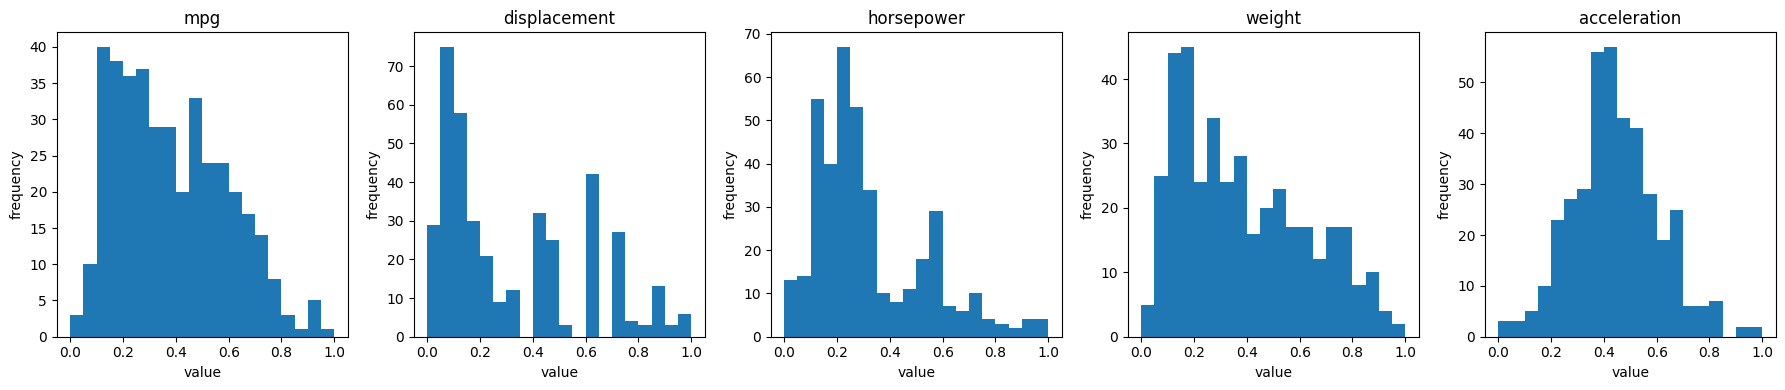

In [26]:
enc = OneHotEncoder()
mini_max_scalar = MinMaxScaler(feature_range=(0, 1))

mpg_df = pd.read_csv('./auto-mpg.csv')
# cost_df
mpg_df_encoded = mpg_df.copy()

# one hot encoding
mpg_df_encoded['one_hot'] = enc.fit_transform(mpg_df[['origin']]).toarray().tolist()
mpg_df_encoded = mpg_df_encoded.drop('origin', axis=1)

# min max normalization
# apply this to each column
for column in mpg_df_encoded.columns[:-1]: # don't apply to one hot
    og_col = mpg_df_encoded[column].tolist()
    og_col = [[x] for x in og_col]
    normalized_col = mini_max_scalar.fit_transform(og_col)
    normalized_col = normalized_col.flatten()
    mpg_df_encoded[column] = normalized_col

# output
print("First five rows of one hot encoding:\n", mpg_df_encoded['one_hot'][:5])
print("----------------------------------------")
print("First five rows of normalized data:\n", mpg_df_encoded[:5])

# plot distribution of each feature
feature_cols = mpg_df_encoded.columns[:-1]
fig, axes = plt.subplots(1, len(feature_cols), figsize=(18, 4))
for ax, col in zip(axes, feature_cols):
    ax.hist(mpg_df_encoded[col], bins=20)
    ax.set_title(col)
    ax.set_xlabel('value')
    ax.set_ylabel('frequency')
plt.tight_layout()
plt.show()


We use one hot encoding because origin is originally a categorical string. The model can't apply math on these but it can apply math on vectors. This removes any arbitrary contained in the strings themselves that may influence the model.

The data for all metrics, excpect for acceleration, is right skewed. You can clearly see that only acceleration has a bell shape, whereas in all other graphs there is a long tail on the right with most of the "mass" of the data being on the left side of teh plot. 

## Bonus Exercise 4 - Logistic Regression
This exercise is not graded, but you should complete it to prepare for the exam and project.

Using the data prepared in Exercise 3 we are going to build a classification model on ``origin`` using the other 5 attributes. <br >
Note that Logistic Regression is a binary classificaiton algorithm.

### Exercise 4.1 - Processing and Splitting the Dataset
In this exercise, we only consider those observations where they originate from either "USA" or "Japan". <br >
So please **remove** those observations that originate from "Europe". <br >
And then, split the data into training and testing set with the ratio of 80:20. <br >

### Exercise 4.2 - Logistic Regression
Using all the other 5 attributes, please build a Logistic Regression model that distinguishes between cars from Japan and cars from the USA. <br >
Then, **if we were distinguishing between Japan and Europe, how do you think the model performance(in terms of accuracy) will change? Provide your reasoning.** (Hint: Exercise 3, how does the distributions of the data vary for the three regions?)

Requirements
 - Report the testing precision and recall for both regions (Japan and USA).